📊 Dashboard Visualization (Real-Time Health Insights)

This module focuses on transforming encrypted wearable data into meaningful visual insights through an interactive dashboard. It bridges the gap between raw data ingestion and user-friendly analytics.

🔹 Core Functionality

Retrieves encrypted wearable data from the backend
Decrypts data securely before processing
Converts raw JSON streams into structured datasets

📈 Data Visualization

Displays key health metrics such as heart rate and step count
Generates time-series trends for activity monitoring
Enables intuitive understanding of user health patterns

🔐 Secure Data Handling

Ensures that all sensitive data is decrypted only at the visualization layer
Maintains end-to-end encryption integrity across the pipeline

⚡ System Highlights

Real-time data fetching from backend APIs
Dynamic chart rendering for continuous updates
Lightweight visualization using Python plotting libraries (Matplotlib)

🧠 Use Case Context
This dashboard serves as the analytical interface of the system, allowing users and administrators to:

Monitor daily activity trends
Detect unusual health patterns visually
Prepare data for machine learning models

📈 Future Enhancements

Integrate React.js for interactive frontend dashboards
Add live streaming charts (WebSocket-based updates)
Include anomaly highlighting and predictive insights
Enable multi-user data filtering and comparison

✨ In short: This module converts encrypted wearable data into clear, actionable visual insights for real-time health monitoring.

In [1]:
!pip install fastapi uvicorn pyngrok cryptography websockets

In [2]:
from fastapi import FastAPI, WebSocket
import uvicorn
from threading import Thread
from cryptography.fernet import Fernet
import json

app = FastAPI()

# Encryption setup
key = Fernet.generate_key()
cipher = Fernet(key)

# Fake DB
database = []

@app.get("/")
def home():
    return {"message": "API running"}

# WebSocket ingestion
@app.websocket("/ws")
async def websocket_endpoint(websocket: WebSocket):
    await websocket.accept()
    while True:
        data = await websocket.receive_text()
        encrypted = cipher.encrypt(data.encode())
        database.append(encrypted)
        await websocket.send_text("Stored securely")

# Data fetch endpoint
@app.get("/data")
def get_data():
    decrypted_data = []
    for item in database:
        decrypted = cipher.decrypt(item).decode()
        decrypted_data.append(json.loads(decrypted))
    return {"data": decrypted_data}

In [3]:
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

Thread(target=run).start()

In [4]:
!ngrok config add-authtoken 3Bld7qqrmmQEgf5tP29blqaApYk_38WQcpAmLd45DtKje2n7f

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [5]:
from fastapi import FastAPI
import uvicorn
from threading import Thread

app = FastAPI()

@app.get("/")
def home():
    return {"message": "API running"}

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

Thread(target=run).start()

INFO:     Started server process [16254]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


In [7]:
from pyngrok import ngrok

ngrok.kill()  # safety
public_url = ngrok.connect(8000)
print(public_url)

NgrokTunnel: "https://matriarchal-boston-unprematurely.ngrok-free.dev" -> "http://localhost:8000"


In [14]:
import asyncio
import websockets
import json

async def send_data():
    # !!! IMPORTANT: Replace 'YOUR_URL.ngrok.io' with the actual public ngrok URL from cell x_gmgGJpWdkP
    uri = "wss://matriarchal-boston-unprematurely.ngrok-free.dev/ws"

    async with websockets.connect(uri) as websocket:
        for i in range(5):
            payload = {
                "heart_rate": 70 + i,
                "steps": 1000 + i*100
            }
            await websocket.send(json.dumps(payload))
            print(await websocket.recv())

# Fix for 'RuntimeError: asyncio.run() cannot be called from a running event loop'
# in Colab, where an event loop is often already running.
await send_data()

INFO:     34.11.46.138:0 - "WebSocket /ws" [accepted]
INFO:     connection open
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/websockets/websockets_impl.py", line 244, in run_asgi
    result = await self.app(self.scope, self.asgi_receive, self.asgi_send)  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist

Stored securely
Stored securely
Stored securely
Stored securely
Stored securely


INFO:     34.11.46.138:0 - "GET /data HTTP/1.1" 200 OK
Status: 200


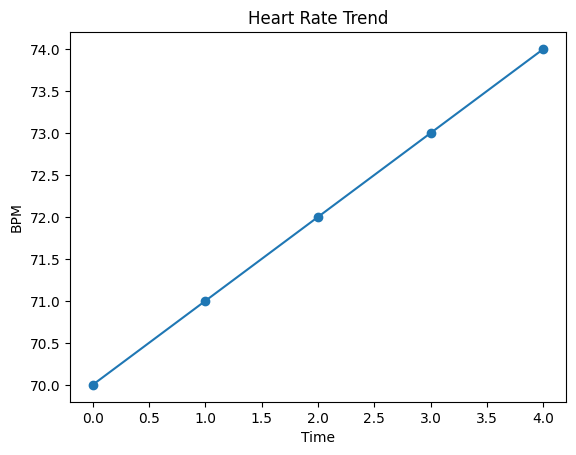

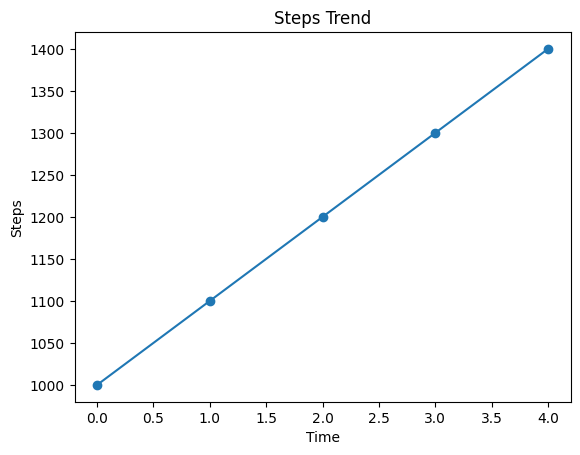

In [15]:
import requests
import matplotlib.pyplot as plt

url = "https://matriarchal-boston-unprematurely.ngrok-free.dev/data"

response = requests.get(url)

print("Status:", response.status_code)

data = response.json()["data"]

heart_rates = [d["heart_rate"] for d in data]
steps = [d["steps"] for d in data]

plt.figure()
plt.plot(heart_rates, marker='o')
plt.title("Heart Rate Trend")
plt.xlabel("Time")
plt.ylabel("BPM")
plt.show()

plt.figure()
plt.plot(steps, marker='o')
plt.title("Steps Trend")
plt.xlabel("Time")
plt.ylabel("Steps")
plt.show()